In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
FILE_PATH = '/content/drive/My Drive/AirbnbRealEstateProject/Dataset/listings.csv'

df = pd.read_csv(FILE_PATH)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 426 rows x 75 columns


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20240905032005,2024-09-05,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20240905032005,2024-09-05,city scrape,Restored Precinct in Center Sq. w/Parking,"Cozy, cool little 1BR Apt in the heart Albany'...","Great restaurants, architecture, walking, peop...",https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,f,4,4,0,0,2.49
2,5651579,https://www.airbnb.com/rooms/5651579,20240905032005,2024-09-05,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.87,4.76,4.63,NaN,f,2,1,1,0,3.22
3,6623339,https://www.airbnb.com/rooms/6623339,20240905032005,2024-09-05,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Large renovated 1 bedroom apartment in convert...,"Located in Albany's finest urban neighborhood,...",https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,f,4,4,0,0,2.91
4,8035768,https://www.airbnb.com/rooms/8035768,20240905032005,2024-09-05,city scrape,Entire Beautiful French Victorian 1884,Stunningly renovated French Victorian original...,There is a Barbershop with 1900' barber chairs...,https://a0.muscache.com/pictures/103429331/a0a...,42430824,...,4.80,4.74,4.75,NaN,f,2,1,1,0,0.51


In [3]:
# See all column names
print(df.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [4]:
# Keep only the columns relevant to our pricing analysis
columns_to_keep = [
    'id', 'name', 'neighbourhood_cleansed', 'latitude', 'longitude',
    'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'price', 'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
    'host_is_superhost', 'host_response_rate', 'calculated_host_listings_count',
    'instant_bookable'
]

df_clean = df[columns_to_keep].copy()

print(f'Shape after selecting columns: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
df_clean.head()

Shape after selecting columns: 426 rows x 22 columns


,id,name,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,...,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,reviews_per_month,host_is_superhost,host_response_rate,calculated_host_listings_count,instant_bookable
0,2992450,Luxury 2 bedroom apartment,THIRD WARD,42.65789,-73.75370,Entire rental unit,Entire home/apt,4,1.0,2.0,...,28,1125,158,9,3.56,0.07,f,NaN,1,f
1,3820211,Restored Precinct in Center Sq. w/Parking,SIXTH WARD,42.65222,-73.76724,Entire rental unit,Entire home/apt,2,1.0,1.0,...,2,1125,336,305,4.75,2.49,f,100%,4,f
2,5651579,Large studio apt by Capital Center & ESP@,SECOND WARD,42.64615,-73.75966,Entire rental unit,Entire home/apt,2,1.0,0.0,...,2,45,34,366,4.51,3.22,f,100%,2,f
3,6623339,Center Sq. Loft in Converted Precinct w/ Parking,SIXTH WARD,42.65222,-73.76724,Entire rental unit,Entire home/apt,2,1.0,1.0,...,2,1125,279,328,4.73,2.91,f,100%,4,f
4,8035768,Entire Beautiful French Victorian 1884,TENTH WARD,42.66088,-73.78147,Entire home,Entire home/apt,6,3.5,3.0,...,2,1125,362,56,4.75,0.51,f,67%,2,f


In [5]:
#check missing values
missing= df_clean.isnull().sum()
missing_pct=(missing/len(df_clean)*100).round(2)
print(pd.DataFrame({'missing':missing,'missing_%':missing_pct})[missing>0])
print()
print(df_clean.dtypes)

                      missing  missing_%
bathrooms                  26       6.10
bedrooms                    5       1.17
beds                       28       6.57
price                      26       6.10
review_scores_rating       60      14.08
reviews_per_month          60      14.08
host_is_superhost           7       1.64
host_response_rate         19       4.46

id                                  int64
name                               object
neighbourhood_cleansed             object
latitude                          float64
longitude                         float64
property_type                      object
room_type                          object
accommodates                        int64
bathrooms                         float64
bedrooms                          float64
beds                              float64
price                              object
minimum_nights                      int64
maximum_nights                      int64
availability_365                    int64


In [6]:
df_clean['price'].head(10)

,price
0,$70.00
1,$116.00
2,$75.00
3,$116.00
4,$305.00
5,$199.00
6,$86.00
7,$65.00
8,$50.00
9,$214.00


In [7]:
# Convert to string first to handle NaN safely, then clean
df_clean['price'] = df_clean['price'].astype(str)
df_clean['price'] = df_clean['price'].str.replace('$', '', regex=False)
df_clean['price'] = df_clean['price'].str.replace(',', '', regex=False)
df_clean['price'] = df_clean['price'].replace('nan', np.nan)
df_clean['price'] = df_clean['price'].astype(float)

print('Price column fixed!')
print(df_clean['price'].describe())

Price column fixed!
count     400.000000
mean      128.482500
std       125.503816
min        24.000000
25%        77.750000
50%       104.000000
75%       139.000000
max      1750.000000
Name: price, dtype: float64


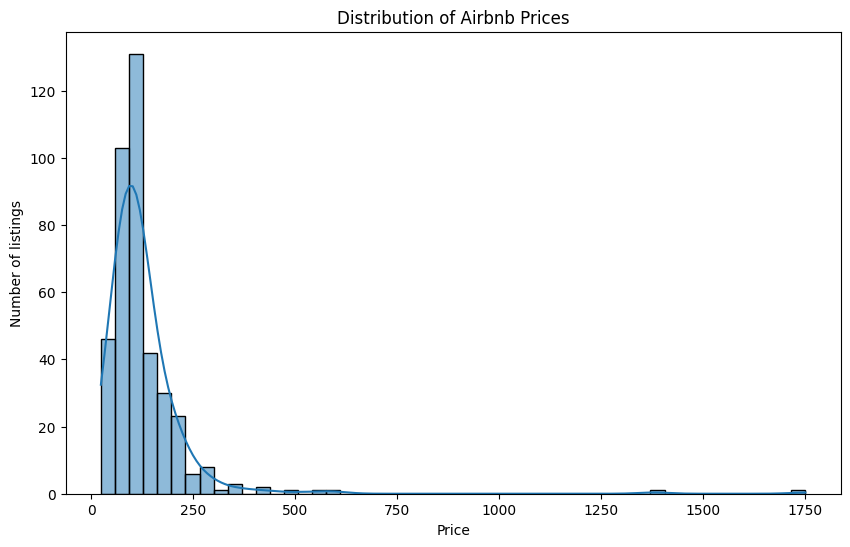

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Number of listings')
plt.show()

In [9]:
# Look at the top 10 most expensive listings
top_expensive = df_clean.sort_values('price', ascending=False).head(10)
top_expensive[['name', 'neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'price']]

,name,neighbourhood_cleansed,property_type,room_type,accommodates,bedrooms,price
335,Charming 1920s house sleeps 6-7,FIFTEENTH WARD,Entire home,Entire home/apt,7,3.0,1750.0
164,One-of-a-Kind Luxe Urban Farmhouse w/ Heated Pool,FOURTEENTH WARD,Entire home,Entire home/apt,12,4.0,1379.0
127,+ Perfect place to make memories with loved on...,TENTH WARD,Entire home,Entire home/apt,12,5.0,600.0
29,/zBig Blue Ranch\ 1962 SUNY Eagle Hill 4Beds 2...,FIFTEENTH WARD,Entire home,Entire home/apt,15,4.0,570.0
101,"/ New Giant Victorian \ 7beds 6 baths + 2x 85""...",THIRTEENTH WARD,Entire home,Entire home/apt,13,5.0,507.0
20,/Sauna Ranch 1961\ SUNY Eagle Hill 4Beds 1Bath,FIFTEENTH WARD,Entire home,Entire home/apt,6,2.0,430.0
320,Mini Mansion,EIGHTH WARD,Entire home,Entire home/apt,14,5.0,423.0
290,Carriage House The Argus Hotel,TENTH WARD,Entire guesthouse,Entire home/apt,6,3.0,364.0
248,Modern Cottage-Perfect for Groups!,FIRST WARD,Entire home,Entire home/apt,8,4.0,361.0
342,Massive 5BD/4BA 3-Story Duplex @ Downtown Albany,SECOND WARD,Entire townhouse,Entire home/apt,16,5.0,356.0


In [10]:
# Price per person = price divided by how many guests it accommodates
df_clean['price_per_person'] = (df_clean['price'] / df_clean['accommodates']).round(2)

# Compare the same top expensive listings using this new metric
df_clean.sort_values('price_per_person', ascending=False).head(10)[
    ['name', 'neighbourhood_cleansed', 'accommodates', 'price', 'price_per_person']
]

,name,neighbourhood_cleansed,accommodates,price,price_per_person
335,Charming 1920s house sleeps 6-7,FIFTEENTH WARD,7,1750.0,250.00
284,Whalen Suite at The Argus Hotel,SIXTH WARD,2,271.0,135.50
164,One-of-a-Kind Luxe Urban Farmhouse w/ Heated Pool,FOURTEENTH WARD,12,1379.0,114.92
406,Albany Vacation Rental w/ State Capitol Views!,SIXTH WARD,2,215.0,107.50
341,Apt,FOURTH WARD,1,105.0,105.00
178,Lovely artist 1 bedroom apartment close to LARK,SIXTH WARD,2,207.0,103.50
5,Delightful French Victorian,TENTH WARD,2,199.0,99.50
280,Hudson 1 at The Argus Hotel,ELEVENTH WARD,2,184.0,92.00
279,Hudson 2 at The Argus Hotel,SIXTH WARD,2,184.0,92.00
281,Hudson 3 ADA at The Argus Hotel,TENTH WARD,2,184.0,92.00


In [11]:
neighbourhood_stats = df_clean.groupby('neighbourhood_cleansed').agg(
    listing_count=('id', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_price_per_person=('price_per_person', 'mean')
).round(2)

neighbourhood_stats = neighbourhood_stats.sort_values('median_price', ascending=False)
neighbourhood_stats

,listing_count,avg_price,median_price,avg_price_per_person
neighbourhood_cleansed,,,,
FIFTEENTH WARD,18,288.71,198.0,51.49
EIGHTH WARD,10,197.67,195.0,49.11
FIRST WARD,8,172.33,144.0,32.61
TWELFTH WARD,5,125.60,125.0,30.16
SECOND WARD,49,138.13,120.0,38.76
FOURTH WARD,14,124.08,115.0,46.02
SIXTH WARD,97,116.05,101.0,46.01
THIRTEENTH WARD,41,115.74,100.0,36.55
FOURTEENTH WARD,22,168.81,99.0,43.34


## Neighbourhood Price Analysis

**Business question:** Which neighbourhoods in Albany command the highest Airbnb prices?

Key findings:
1. Albany shows a clear two-tier pricing market.
2. Fifteenth Ward ($198) and Eighth Ward ($195) are premium neighbourhoods nearly double the most affordable areas.
3. The majority of neighbourhoods cluster tightly between $95-$125 per night.
4. Sixth Ward is the most active market (97 listings) yet sits right at the median price ($101) suggesting high supply keeps prices competitive.

5. Seventh Ward offers the most affordable stays at $95 median despite being in the same city.

**Note:** Median price used instead of average to reduce the impact of luxury outlier listings.

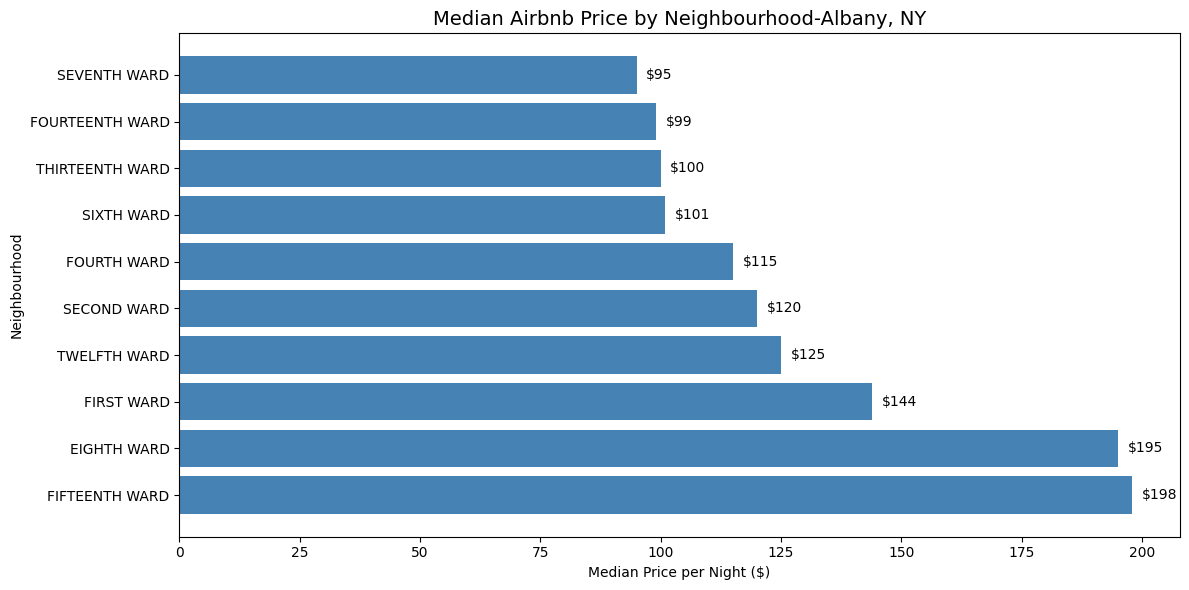

In [13]:
# Get top 10 neighbourhoods by listing count for cleaner chart
top_neighbourhoods = neighbourhood_stats.head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(
    top_neighbourhoods.index,
    top_neighbourhoods['median_price'],
    color='steelblue'
)

# Add price labels on each bar
for bar, price in zip(bars, top_neighbourhoods['median_price']):
    plt.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height()/2,
        f'${price:.0f}',
        va='center',
        fontsize=10
    )

plt.title('Median Airbnb Price by Neighbourhood-Albany, NY', fontsize=14)
plt.xlabel('Median Price per Night ($)')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()

In [14]:
print(df_clean['room_type'].value_counts())

room_type
Entire home/apt    310
Private room       114
Shared room          2
Name: count, dtype: int64


## Room Type Price Comparison

**Business question:** Does room type significantly affect nightly price?

Key findings:
- Entire homes command roughly 2x the price of private rooms
- Entire home median: ~$120/night vs Private room median: ~$65/night
- Entire homes show much wider price variation ($50-$600+) - driven by property size and neighbourhood
- Private rooms are more predictably priced, clustering tightly between $50-$100
- Shared rooms were excluded from analysis (only 2 listings - not statistically meaningful)

/tmp/ipykernel_639/1739466262.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


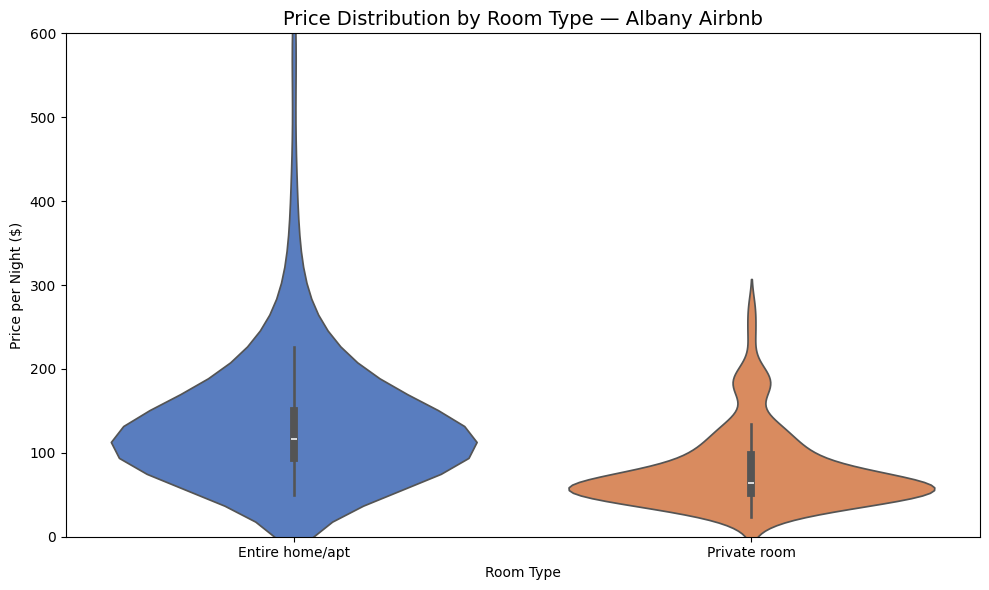

In [15]:
# Filter out shared rooms — only 2 listings, not meaningful
df_plot = df_clean[df_clean['room_type'] != 'Shared room']

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_plot,
    x='room_type',
    y='price',
    palette='muted'
)

plt.title('Price Distribution by Room Type - Albany Airbnb', fontsize=14)
plt.xlabel('Room Type')
plt.ylabel('Price per Night ($)')
plt.ylim(0, 600)  # cap at $600 to ignore extreme outliers visually
plt.tight_layout()
plt.show()

In [16]:
print(df_clean['host_is_superhost'].value_counts())

host_is_superhost
t    233
f    186
Name: count, dtype: int64


In [17]:
# Clean the superhost column first — t/f → Yes/No for readability
df_clean['host_is_superhost'] = df_clean['host_is_superhost'].map({'t': 'Superhost', 'f': 'Not Superhost'})

# Calculate stats for each group
superhost_stats = df_clean.groupby('host_is_superhost').agg(
    listing_count=('id', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_review_score=('review_scores_rating', 'mean')
).round(2)

print(superhost_stats)

                   listing_count  avg_price  median_price  avg_review_score
host_is_superhost                                                          
Not Superhost                186     123.37         105.0              4.62
Superhost                    233     133.95         105.5              4.87


## Superhost vs Non-Superhost Analysis

**Business question:** Do superhosts charge more, and does the badge actually matter?

Key findings:
- Median prices are nearly identical - $105 (non-superhost) vs $105.50 (superhost)
- Superhosts have a higher average price ($134 vs $123) - driven by more premium/larger listings
- The real superhost advantage is review scores: 4.87 vs 4.62
- In Airbnb's algorithm, higher review scores = better search ranking = more bookings
- Superhost status signals quality to guests rather than justifying a direct price premium

/tmp/ipykernel_639/2556503208.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


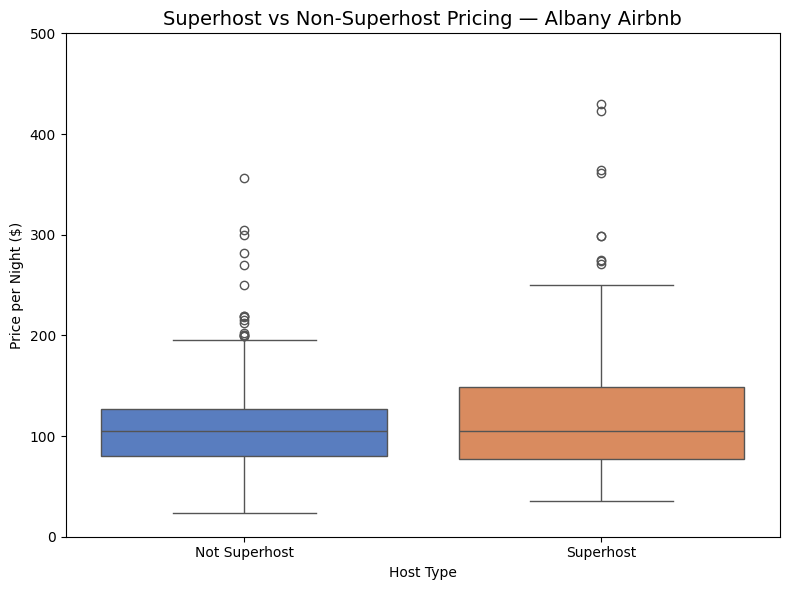

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_clean,
    x='host_is_superhost',
    y='price',
    palette='muted'
)

plt.title('Superhost vs Non-Superhost Pricing — Albany Airbnb', fontsize=14)
plt.xlabel('Host Type')
plt.ylabel('Price per Night ($)')
plt.ylim(0, 500)
plt.tight_layout()
plt.show()

## Correlation Analysis - What Actually Drives Price?

**Business question:** Which listing features have the strongest relationship with nightly price?

Key findings:
- Accommodates (0.53) is the strongest price driver - bigger capacity = higher price
- Bedrooms (0.44) and beds (0.42) are the next strongest - all size-related metrics
- Review scores have almost no correlation with price (0.09) - guests pay for space, not stars
- Accommodates, bedrooms and beds are highly correlated with each other (0.75-0.78) - measuring the same underlying concept: property size
- price_per_person negatively correlates with accommodates (-0.33) - confirming group stays offer better per-person value
- Minimum nights and availability show virtually no price relationship

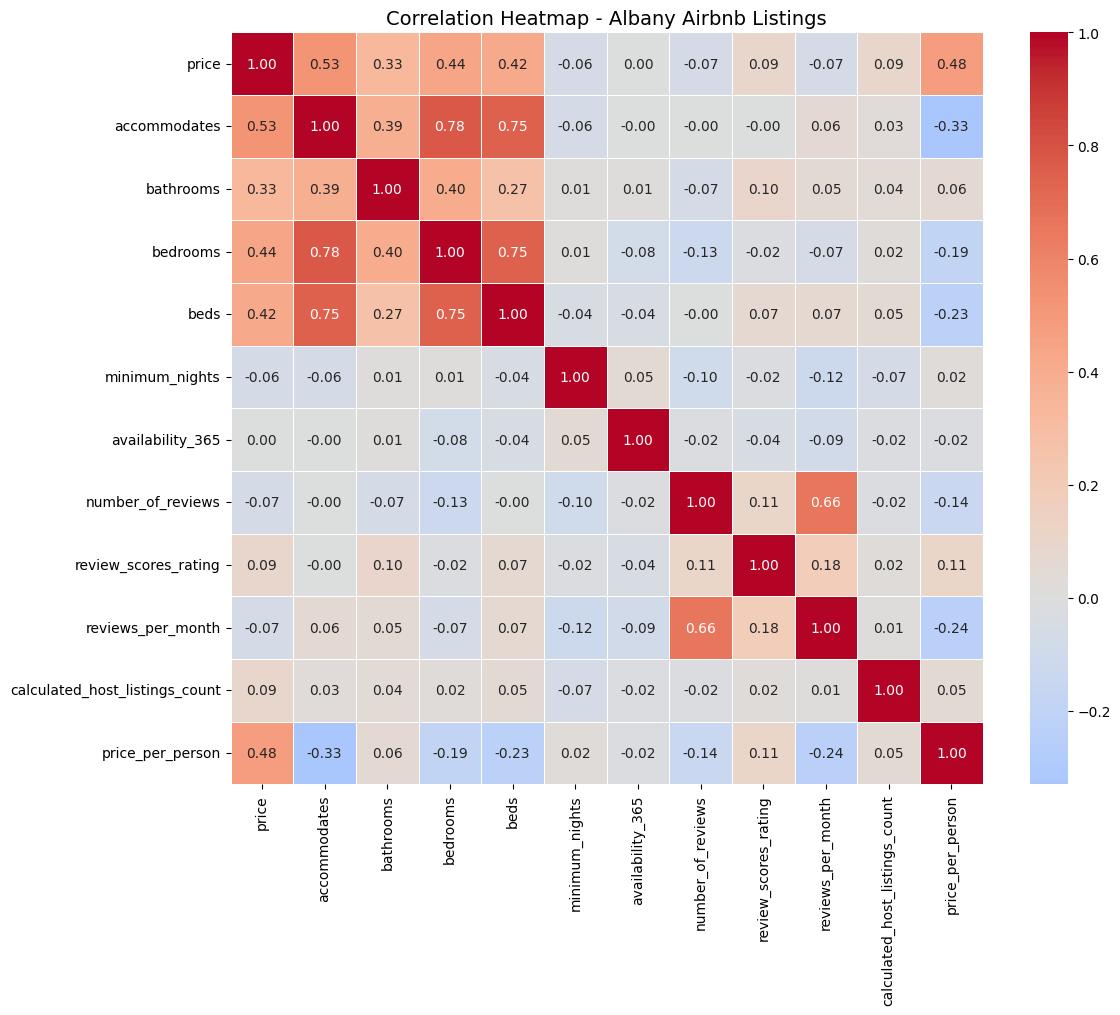

In [20]:
# Select only numeric columns for correlation
numeric_cols = [
    'price', 'accommodates', 'bathrooms', 'bedrooms',
    'beds', 'minimum_nights', 'availability_365',
    'number_of_reviews', 'review_scores_rating',
    'reviews_per_month', 'calculated_host_listings_count',
    'price_per_person'
]

# Calculate correlation matrix
corr_matrix = df_clean[numeric_cols].corr().round(2)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap - Albany Airbnb Listings', fontsize=14)
plt.tight_layout()
plt.show()

## Review Score vs Price Analysis

**Business question:** Do higher rated listings charge more?

Key findings:
- No clear relationship between review score and price (confirmed correlation: 0.09)
- Listings across ALL price points cluster at 4.8-5.0 ratings
- A $30 private room and a $600 entire home can both earn perfect 5-star ratings
- This suggests guests rate relative to price expectations, not absolute quality
- The most expensive listings (large entire homes, big blue dots) tend to have high ratings - but so do the cheapest
- Room type (colour) and property size (dot size) explain price variation far better than review scores

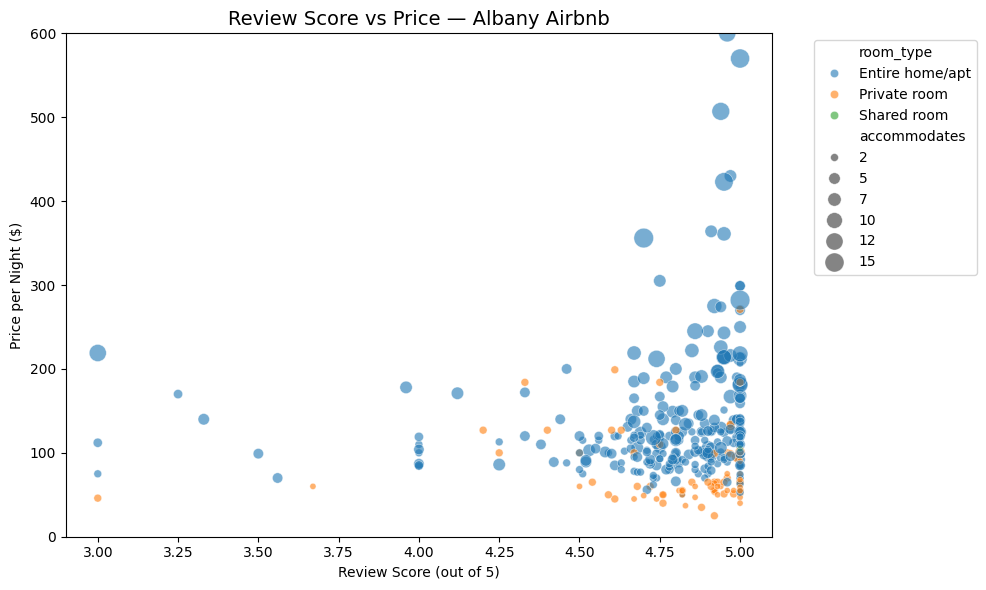

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean.dropna(subset=['review_scores_rating', 'price']),
    x='review_scores_rating',
    y='price',
    hue='room_type',
    alpha=0.6,
    size='accommodates',
    sizes=(20, 200)
)

plt.title('Review Score vs Price — Albany Airbnb', fontsize=14)
plt.xlabel('Review Score (out of 5)')
plt.ylabel('Price per Night ($)')
plt.ylim(0, 600)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()